# Malaria Recovery Prediction: A Logic-Based Approach using CBC Data

## About this Notebook:

This notebook explores the use of a Decision Tree Classifier to identify the recovery phase of a Malaria patient based on Complete Blood Count (CBC) parameters.

## Key Insight:

During recovery, certain patterns emerge in the blood profile. For instance, in this case study:

* Hemoglobin (HGB): Stable at 13.4 g/dL.
* Platelets (PLT): Recovered to 270 x10^9/L, indicating successful treatment.
* MID%: Elevated to 15.8%, reflecting the immune system's role in clearing remnants of the infection.
* RDW-CV: Slightly high at 15.3%, showing active production of new red blood cells.

## Goal:

To demonstrate how simple Machine Learning logic can assist in monitoring patient progress during post-infection phases.

## Author:
Samir M. Idris<br>
Sr. Software Engineer, MSc.IT<br>
https://www.kaggle.com/samirmidris<br>
samir.idris@hotmail.com


In [1]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


# Training Data:

In [2]:
# Training data: Patterns the AI learns from
data = {
    'HGB': [14.5, 13.4, 9.5, 15.2, 10.8, 13.0, 11.5],
    'PLT': [300, 270, 75, 280, 110, 260, 90],
    'MID_percent': [5.0, 15.8, 22.0, 6.0, 18.5, 14.0, 25.0],
    'Diagnosis': [0, 1, 2, 0, 2, 1, 2] # 0:Healthy, 1:Recovery, 2:Infection
}
df = pd.DataFrame(data)
df

,HGB,PLT,MID_percent,Diagnosis
0,14.5,300,5.0,0
1,13.4,270,15.8,1
2,9.5,75,22.0,2
3,15.2,280,6.0,0
4,10.8,110,18.5,2
5,13.0,260,14.0,1
6,11.5,90,25.0,2


# Visualization:

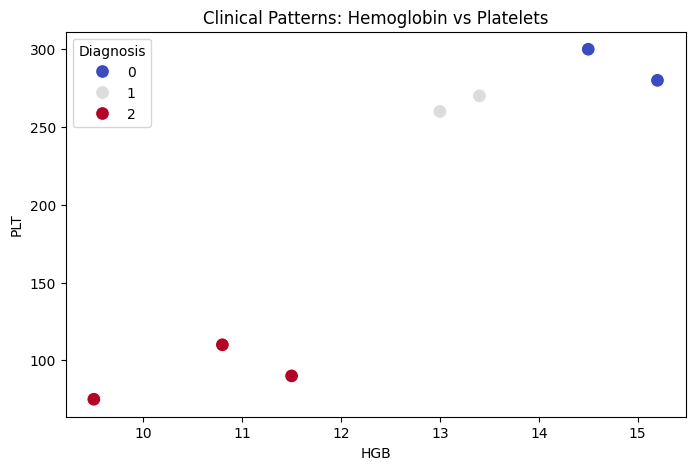

In [3]:
# Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='HGB', y='PLT', hue='Diagnosis', palette='coolwarm', s=100)
plt.title('Clinical Patterns: Hemoglobin vs Platelets')
plt.show()

# Model Training:

In [4]:
# Model Training
X = df[['HGB', 'PLT', 'MID_percent']]
y = df['Diagnosis']

model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

print("Model trained and ready for prediction!")

Model trained and ready for prediction!


# Prediction:

RESULT: Recovery Phase


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


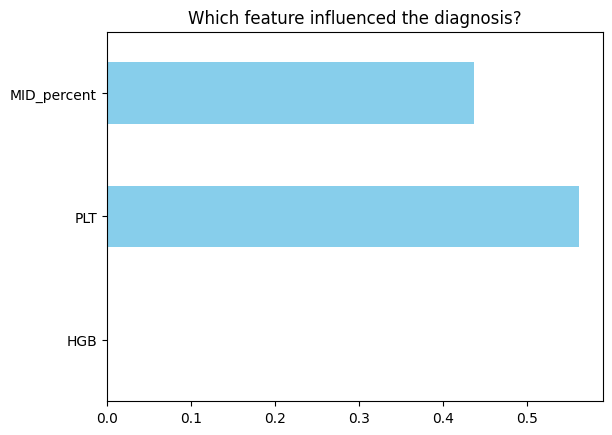

In [5]:
# Prediction
# This is real data from a real CBC report (case study of specific patient)
# HGB: 13.4, PLT: 270, MID%: 15.8
my_data = [[13.4, 270, 15.8]]

prediction = model.predict(my_data)

status_map = {0: "Healthy", 1: "Recovery Phase", 2: "Active Infection"}
print(f"RESULT: {status_map[prediction[0]]}")

# Show why this decision was made
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.plot(kind='barh', color='skyblue')
plt.title('Which feature influenced the diagnosis?')
plt.show()

# Finally!

In [6]:
# Model accuracy on the training data
# How confident the model is!
# Note that the training data is very-small in this case.
accuracy = model.score(X, y) * 100
print(f"Model Training Accuracy: {accuracy:.2f}%")

Model Training Accuracy: 100.00%
